# Crime Data Analysis, Visualization, and Predictive Route Safety

Pipeline: **load & preprocess -> exploratory analysis -> interactive maps -> Random Forest model -> route safety scoring.**

Run from the `notebooks/` folder. Inputs live in `../data/`, generated maps are written to `../maps/`.

> The dataset is a small illustrative sample (43 records, 4 neighbourhoods, 2022) and the neighbourhood
> coordinates in `locations.csv` are representative points, not surveyed boundaries. Results demonstrate the
> method, not real-world crime patterns.

## 1. Setup

In [1]:
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import seaborn as sns
from folium.plugins import HeatMap
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict

pio.renderers.default = "plotly_mimetype+notebook_connected"
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data")
MAPS_DIR = Path("../maps")
MAPS_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

# Relative harm of one incident of each crime type (used for risk scoring)
CRIME_SEVERITY = {"Theft": 1, "Assault": 3, "Burglary": 2}

## 2. Data ingestion and preprocessing (spatial & temporal encoding)

- **Ingestion:** crime logs from `crime_data.csv`, neighbourhood coordinates from `locations.csv`.
- **Spatial encoding:** each record is joined to its neighbourhood's latitude / longitude.
- **Temporal encoding:** month and day-of-week are encoded cyclically (sin/cos) so December and January are
  treated as neighbours rather than 11 units apart.

In [2]:
crimes = pd.read_csv(DATA_DIR / "crime_data.csv", parse_dates=["Date"])
locations = pd.read_csv(DATA_DIR / "locations.csv")

# Fail early on data problems instead of producing silently wrong analysis
assert not crimes.isna().any().any(), "missing values in crime_data.csv"
unknown = set(crimes["Location"]) - set(locations["Location"])
assert not unknown, f"locations without coordinates: {unknown}"
assert set(crimes["Crime_Type"]) <= set(CRIME_SEVERITY), "crime type missing a severity weight"

df = crimes.merge(locations, on="Location", how="left")

# Temporal features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)
df["Dow_sin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
df["Dow_cos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

# Severity-weighted risk of each record
df["Severity"] = df["Crime_Type"].map(CRIME_SEVERITY)
df["Risk_Score"] = df["Severity"] * df["Crime_Count"]

print(f"{len(df)} records | {df['Date'].min():%Y-%m-%d} to {df['Date'].max():%Y-%m-%d}")
df.head()

43 records | 2022-01-05 to 2022-12-15


,Date,Location,Crime_Type,Crime_Count,Latitude,Longitude,Year,Month,DayOfWeek,Month_sin,Month_cos,Dow_sin,Dow_cos,Severity,Risk_Score
0,2022-01-05,Downtown,Theft,5,40.7128,-74.0060,2022,1,2,0.500000,0.866025,0.974928,-0.222521,1,5
1,2022-01-10,Uptown,Assault,2,40.8116,-73.9465,2022,1,0,0.500000,0.866025,0.000000,1.000000,3,6
2,2022-01-15,Suburb,Burglary,3,40.7282,-73.7949,2022,1,5,0.500000,0.866025,-0.974928,-0.222521,2,6
3,2022-02-01,Downtown,Theft,4,40.7128,-74.0060,2022,2,1,0.866025,0.500000,0.781831,0.623490,1,4
4,2022-02-05,Midtown,Theft,6,40.7549,-73.9840,2022,2,5,0.866025,0.500000,-0.974928,-0.222521,1,6


## 3. Exploratory data analysis

In [3]:
print("Total crimes by location and type")
display(df.pivot_table(index="Location", columns="Crime_Type", values="Crime_Count", aggfunc="sum", fill_value=0, margins=True))

print("Summary of Crime_Count per incident record")
display(df["Crime_Count"].describe().round(2).to_frame().T)

print("Records by crime type")
display(df["Crime_Type"].value_counts().to_frame("records"))

Total crimes by location and type


Crime_Type,Assault,Burglary,Theft,All
Location,,,,
Downtown,7,0,68,75
Midtown,0,0,38,38
Suburb,0,68,0,68
Uptown,43,0,4,47
All,50,68,110,228


Summary of Crime_Count per incident record


,count,mean,std,min,25%,50%,75%,max
Crime_Count,43.0,5.3,2.17,1.0,4.0,5.0,7.0,9.0


Records by crime type


,records
Crime_Type,
Theft,20
Assault,12
Burglary,11


### 3.1 Temporal distribution

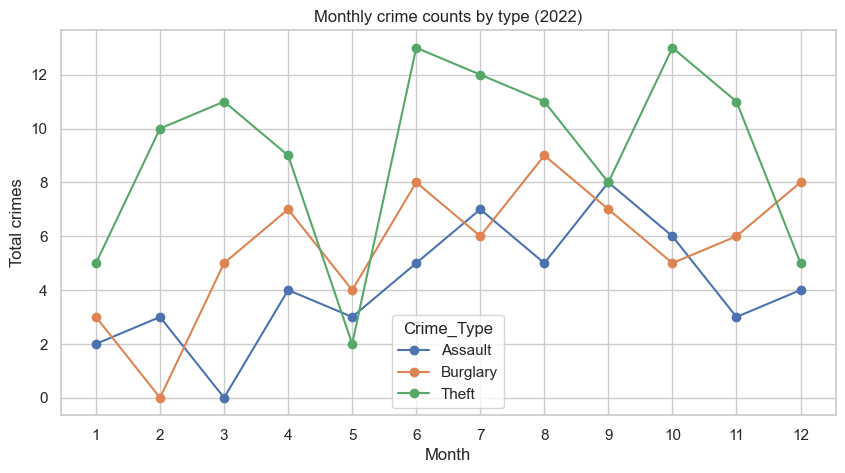

In [4]:
monthly = df.groupby(["Month", "Crime_Type"])["Crime_Count"].sum().unstack(fill_value=0)

ax = monthly.plot(kind="line", marker="o", figsize=(10, 5))
ax.set_title("Monthly crime counts by type (2022)")
ax.set_xlabel("Month")
ax.set_ylabel("Total crimes")
ax.set_xticks(range(1, 13))
plt.show()

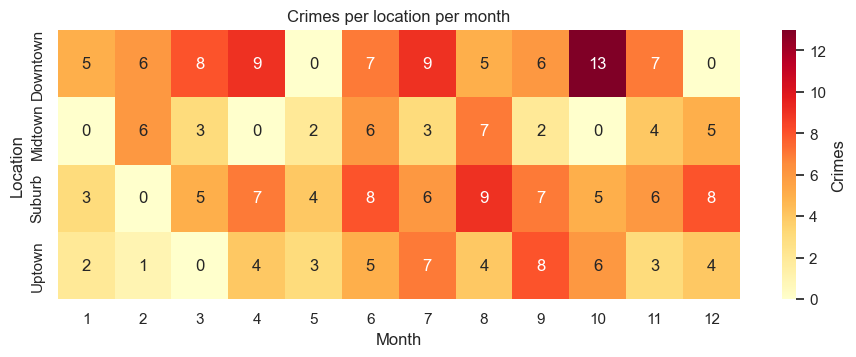

In [5]:
heat = df.pivot_table(index="Location", columns="Month", values="Crime_Count", aggfunc="sum", fill_value=0)

plt.figure(figsize=(11, 3.5))
sns.heatmap(heat, annot=True, fmt="g", cmap="YlOrRd", cbar_kws={"label": "Crimes"})
plt.title("Crimes per location per month")
plt.show()

### 3.2 Spatial distribution

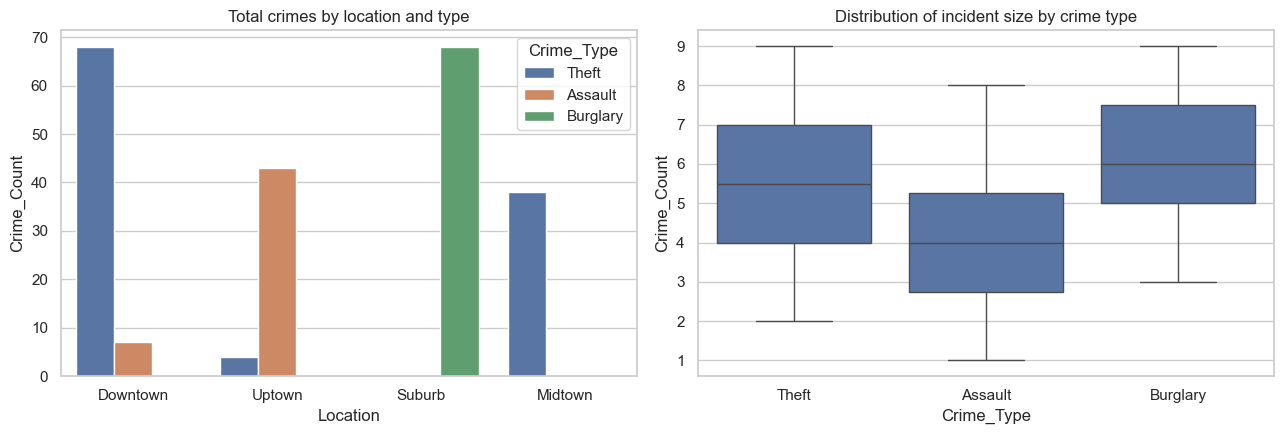

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(data=df, x="Location", y="Crime_Count", hue="Crime_Type", estimator=sum, errorbar=None, ax=axes[0])
axes[0].set_title("Total crimes by location and type")

sns.boxplot(data=df, x="Crime_Type", y="Crime_Count", ax=axes[1])
axes[1].set_title("Distribution of incident size by crime type")

plt.tight_layout()
plt.show()

### 3.3 Interactive charts (Plotly)

In [7]:
fig = px.bar(
    df.groupby(["Location", "Crime_Type"], as_index=False)["Crime_Count"].sum(),
    x="Location", y="Crime_Count", color="Crime_Type",
    title="Crime by location and type",
)
fig.show()

fig = px.line(
    df.sort_values("Date"), x="Date", y="Crime_Count", color="Location", markers=True,
    hover_data=["Crime_Type"], title="Crime counts over time by location",
)
fig.show()

## 4. Interactive geospatial maps (Folium & Plotly)

Per-neighbourhood totals are drawn as sized markers and as a weighted density heatmap. Both are saved as
standalone HTML files in `../maps/`.

In [8]:
by_loc = (
    df.groupby(["Location", "Latitude", "Longitude"], as_index=False)
    .agg(Total_Crimes=("Crime_Count", "sum"), Risk_Score=("Risk_Score", "sum"))
)
top_type = df.groupby(["Location", "Crime_Type"])["Crime_Count"].sum().groupby("Location").idxmax().str[1]
by_loc["Top_Crime"] = by_loc["Location"].map(top_type)
by_loc

,Location,Latitude,Longitude,Total_Crimes,Risk_Score,Top_Crime
0,Downtown,40.7128,-74.0060,75,89,Theft
1,Midtown,40.7549,-73.9840,38,38,Theft
2,Suburb,40.7282,-73.7949,68,136,Burglary
3,Uptown,40.8116,-73.9465,47,133,Assault


In [9]:
center = [by_loc["Latitude"].mean(), by_loc["Longitude"].mean()]

# --- Marker map: circle area proportional to total crimes, colour by severity-weighted risk
marker_map = folium.Map(location=center, zoom_start=11, tiles="cartodbpositron")
risk_max = by_loc["Risk_Score"].max()
for _, r in by_loc.iterrows():
    folium.CircleMarker(
        location=[r["Latitude"], r["Longitude"]],
        radius=6 + 22 * np.sqrt(r["Total_Crimes"] / by_loc["Total_Crimes"].max()),
        color="crimson" if r["Risk_Score"] >= 0.75 * risk_max else "steelblue",
        fill=True, fill_opacity=0.6,
        popup=folium.Popup(
            f"<b>{r['Location']}</b><br>Total crimes: {r['Total_Crimes']}<br>"
            f"Risk score: {r['Risk_Score']}<br>Most common: {r['Top_Crime']}",
            max_width=220,
        ),
    ).add_to(marker_map)
marker_map.save(MAPS_DIR / "crime_markers_map.html")

# --- Heatmap: every incident weighted by its severity-adjusted count
heat_map = folium.Map(location=center, zoom_start=11, tiles="cartodbpositron")
HeatMap(df[["Latitude", "Longitude", "Risk_Score"]].values.tolist(), radius=45, blur=35).add_to(heat_map)
heat_map.save(MAPS_DIR / "crime_heatmap.html")

marker_map

c:\users\dell\appdata\local\temp\claude\c--users-dell-downloads\b28933a4-1605-40e5-b194-05f9abc40ae1\scratchpad\nbenv\lib\site-packages\folium\raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [10]:
# Plotly density view of the same data
fig = px.scatter_map(
    by_loc, lat="Latitude", lon="Longitude", size="Total_Crimes", color="Risk_Score",
    hover_name="Location", hover_data=["Top_Crime"], color_continuous_scale="YlOrRd",
    size_max=45, zoom=9.5, map_style="carto-positron", title="Crime volume and risk by neighbourhood",
)
fig.show()

## 5. Predictive model: Random Forest crime intensity

**Target:** `Crime_Count` per incident record.
**Features:** neighbourhood coordinates (spatial), cyclical month and weekday (temporal), crime type severity.

With only 43 records a single train/test split is unreliable, so performance is estimated with 5-fold
cross-validation and compared to a naive baseline (each neighbourhood's mean count). A model that does not beat
the baseline has not learned anything useful.

In [11]:
FEATURES = ["Latitude", "Longitude", "Month_sin", "Month_cos", "Dow_sin", "Dow_cos", "Severity"]
X, y = df[FEATURES], df["Crime_Count"]

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
model = RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=RANDOM_STATE)

rf_pred = cross_val_predict(model, X, y, cv=cv)

# Baseline: mean count of the training folds' records for the same neighbourhood
base_pred = np.zeros(len(df))
for train_idx, test_idx in cv.split(X):
    loc_mean = df.iloc[train_idx].groupby("Location")["Crime_Count"].mean()
    base_pred[test_idx] = df.iloc[test_idx]["Location"].map(loc_mean).fillna(y.iloc[train_idx].mean())

def report(name, pred):
    return {
        "model": name,
        "MAE": mean_absolute_error(y, pred),
        "RMSE": np.sqrt(mean_squared_error(y, pred)),
        "R2": r2_score(y, pred),
    }

pd.DataFrame([report("Location-mean baseline", base_pred), report("Random Forest", rf_pred)]).set_index("model").round(3)

,MAE,RMSE,R2
model,,,
Location-mean baseline,1.746,2.069,0.066
Random Forest,1.871,2.203,-0.059


**Reading the result:** compare the two rows. If the Random Forest's error is not clearly below the baseline
(and R2 is near or below zero), the features carry no learnable signal on this sample. That is the expected
outcome for 43 near-random synthetic records, and it is reported as-is rather than tuned away. The same code
applies unchanged to a larger real dataset, where the comparison becomes meaningful.

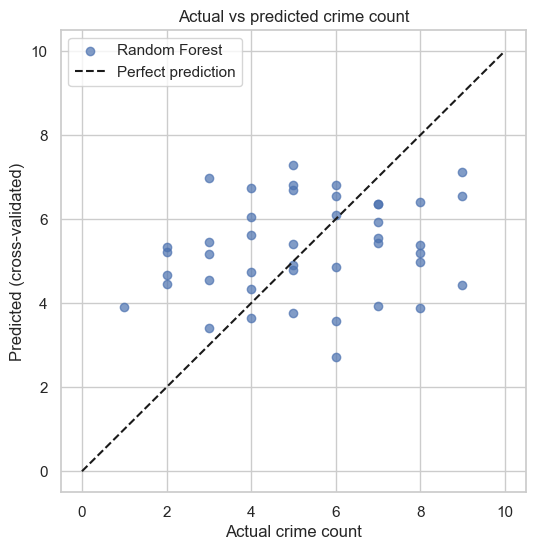

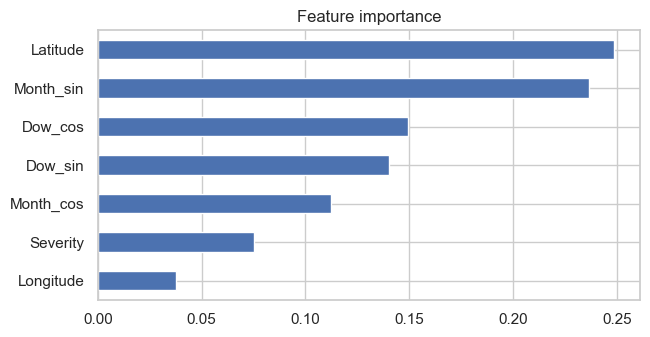

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y, rf_pred, alpha=0.7, label="Random Forest")
lims = [0, max(y.max(), rf_pred.max()) + 1]
ax.plot(lims, lims, "k--", label="Perfect prediction")
ax.set(xlabel="Actual crime count", ylabel="Predicted (cross-validated)", title="Actual vs predicted crime count")
ax.legend()
plt.show()

model.fit(X, y)
importance = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
importance.plot(kind="barh", figsize=(7, 3.5), title="Feature importance")
plt.show()

### 5.1 Forecast: expected crime intensity by neighbourhood

The fitted model predicts the count for each neighbourhood x crime type observed there, for each month of the
first quarter of 2023 (mid-month, Wednesday). Predictions are summed per neighbourhood and severity-weighted into
a **predicted risk score**, which feeds the route safety analysis below.

In [13]:
combos = df[["Location", "Latitude", "Longitude", "Crime_Type", "Severity"]].drop_duplicates()
future_months = pd.date_range("2023-01-15", periods=3, freq="MS") + pd.Timedelta(days=14)

rows = []
for date in future_months:
    f = combos.copy()
    f["Date"] = date
    f["Month_sin"] = np.sin(2 * np.pi * date.month / 12)
    f["Month_cos"] = np.cos(2 * np.pi * date.month / 12)
    f["Dow_sin"] = np.sin(2 * np.pi * date.dayofweek / 7)
    f["Dow_cos"] = np.cos(2 * np.pi * date.dayofweek / 7)
    rows.append(f)
future = pd.concat(rows, ignore_index=True)
future["Predicted_Count"] = model.predict(future[FEATURES])
future["Predicted_Risk"] = future["Predicted_Count"] * future["Severity"]

forecast = (
    future.groupby(["Location", "Latitude", "Longitude"], as_index=False)
    .agg(Predicted_Count=("Predicted_Count", "sum"), Predicted_Risk=("Predicted_Risk", "sum"))
    .sort_values("Predicted_Risk", ascending=False)
    .round(1)
)
forecast

,Location,Latitude,Longitude,Predicted_Count,Predicted_Risk
0,Downtown,40.7,-74.0,31.3,59.7
3,Uptown,40.8,-73.9,21.7,41.5
2,Suburb,40.7,-73.8,15.7,31.4
1,Midtown,40.8,-74.0,12.1,12.1


## 6. Route safety scoring

A route is an ordered list of neighbourhoods joined by straight segments. Instead of just summing the
neighbourhoods on the list, the route is **sampled every ~250 m** and, at each sample point, crime density is
estimated with a Gaussian kernel over the neighbourhood risk scores (nearby areas count more, distant areas
fade out with a 3 km bandwidth). A route's **exposure** is the density integrated along its length, so both
passing through high-risk areas and spending longer near them raise the score.

In [14]:
EARTH_KM = 6371.0
BANDWIDTH_KM = 3.0
STEP_KM = 0.25

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * EARTH_KM * np.arcsin(np.sqrt(a))

def sample_route(waypoints, step_km=STEP_KM):
    """Return points every ~step_km along the polyline through `waypoints` (list of (lat, lon))."""
    points = []
    for (la1, lo1), (la2, lo2) in zip(waypoints[:-1], waypoints[1:]):
        n = max(int(np.ceil(haversine_km(la1, lo1, la2, lo2) / step_km)), 1)
        t = np.linspace(0, 1, n, endpoint=False)
        points += list(zip(la1 + t * (la2 - la1), lo1 + t * (lo2 - lo1)))
    points.append(waypoints[-1])
    return np.array(points)

def crime_density(points, risk_table):
    """Gaussian-kernel crime density (risk per neighbourhood, distance-weighted) at each point."""
    density = np.zeros(len(points))
    for _, r in risk_table.iterrows():
        d = haversine_km(points[:, 0], points[:, 1], r["Latitude"], r["Longitude"])
        density += r["Risk"] * np.exp(-0.5 * (d / BANDWIDTH_KM) ** 2)
    return density

def score_route(names, risk_table):
    coords = risk_table.set_index("Location").loc[names, ["Latitude", "Longitude"]].values
    pts = sample_route([tuple(c) for c in coords])
    dens = crime_density(pts, risk_table)
    length_km = sum(haversine_km(*a, *b) for a, b in zip(coords[:-1], coords[1:]))
    return {
        "length_km": length_km,
        "exposure": dens.sum() * STEP_KM,          # density integrated along the path
        "risk_per_km": dens.sum() * STEP_KM / length_km,
        "points": pts, "density": dens,
    }

In [15]:
# Risk surface = forecasted risk per neighbourhood
risk_table = forecast.rename(columns={"Predicted_Risk": "Risk"})[["Location", "Latitude", "Longitude", "Risk"]]

routes = {
    "Route A: Suburb > Uptown > Downtown": ["Suburb", "Uptown", "Downtown"],
    "Route B: Suburb > Midtown > Downtown": ["Suburb", "Midtown", "Downtown"],
    "Route C: Suburb > Downtown (direct)": ["Suburb", "Downtown"],
}

scores = {name: score_route(stops, risk_table) for name, stops in routes.items()}
summary = pd.DataFrame(
    {n: {k: s[k] for k in ("length_km", "exposure", "risk_per_km")} for n, s in scores.items()}
).T.round(2).sort_values("exposure")

safest = summary.index[0]
display(summary)
print(f"Safest route by total exposure: {safest}")
print(f"Safest route by exposure per km: {summary['risk_per_km'].idxmin()}")

,length_km,exposure,risk_per_km
Route C: Suburb > Downtown (direct),16.86,357.13,21.18
Route B: Suburb > Midtown > Downtown,31.31,549.09,17.54
Route A: Suburb > Uptown > Downtown,27.90,675.82,24.22


Safest route by total exposure: Route C: Suburb > Downtown (direct)
Safest route by exposure per km: Route B: Suburb > Midtown > Downtown


**Two metrics, two answers:** *total exposure* favours short routes (less distance, less time near crime), while
*exposure per km* shows how risky each kilometre is, which favours routes that spend more of their length away
from hotspots. Which to prefer depends on whether the traveller is limited by time or by risk tolerance.

In [16]:
# Overlay routes on the crime density heatmap; colour = relative exposure (green safest -> red riskiest)
route_map = folium.Map(location=center, zoom_start=11, tiles="cartodbpositron")
HeatMap(
    [[r["Latitude"], r["Longitude"], r["Risk"]] for _, r in risk_table.iterrows()],
    radius=60, blur=40, min_opacity=0.25,
).add_to(route_map)

palette = ["green", "orange", "red"]
for colour, (name, s) in zip(palette, sorted(scores.items(), key=lambda kv: kv[1]["exposure"])):
    folium.PolyLine(
        s["points"].tolist(), color=colour, weight=5, opacity=0.85,
        tooltip=f"{name} | {s['length_km']:.1f} km | exposure {s['exposure']:.0f}",
    ).add_to(route_map)

for _, r in risk_table.iterrows():
    folium.Marker([r["Latitude"], r["Longitude"]], tooltip=f"{r['Location']} (forecast risk {r['Risk']:.0f})").add_to(route_map)

route_map.save(MAPS_DIR / "route_safety_map.html")
route_map

c:\users\dell\appdata\local\temp\claude\c--users-dell-downloads\b28933a4-1605-40e5-b194-05f9abc40ae1\scratchpad\nbenv\lib\site-packages\folium\raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


## 7. Limitations

- 43 records over one year: cross-validated error is only a rough guide, and month effects come from a single
  year of data, so the Q1 2023 forecast is a seasonal repeat of 2022 patterns.
- Neighbourhoods are single representative points, and routes are straight segments between them rather than
  real road networks.
- Severity weights (Theft 1, Burglary 2, Assault 3) are illustrative assumptions.